In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import multiprocessing
import fmm3dpy as fmm

In [2]:
num_files = 1 #in a parameter scan, num_files > 1.  For the example in the git repo, num_files=1

In [3]:
'''
reads in output data file from Doppler laser cooling simulation
creates 3d array 'data_par' to hold data [ [ [x_i1_t0, x_i2_t0, x_p3_t0, ...],[y_i1_t0, y_i2_t0, ...], ... ],
                                           [ [x_i1_t1, x_i2_t1, x_i3_t1, ...],[y_i1_t1, y_i2_t1, ...], ... ],
                                           . . .
                                           [ [x_i1_tn, x_i2_tn, x_p3_tn, ...],[y_i1_tn, y_i2_tn, ...], ... ] ]

first index in data_par specifies timestep
second index specifies data type, i.e. cartesian component of pos. or vel (0=x, 1=y, 2=z, 3=v_x, 4=v_y, 5=v_z)
third index specifies ion index
'''

data_par = np.array([])

def read_output(file_num, ret_params=False):
    #to read a single output file (num_files=1), the index file_num can be ignored
    f = open("output/output_100i_091026.txt", "rb") #change path to reflect location of output file
    
    print("file: " + str(file_num))


    gaussian2D=True
    places=4
    ########## read number of particles (first number in data file) ##########
    char_len = 1
    char_empty = False
    while not char_empty:
        f.seek(0)  #go to first character in file
        data_byte = f.read(char_len)
        num_particles = int(data_byte)
        char_len+=1
        next_char = f.read(1)
        if next_char ==  b" ":
            char_empty = True

    print("Num particles: " + str(num_particles))

    ########## read number of recorded timesteps ##########
    rec_steps = float(f.read(14))  #non-negative number in scientific notation has 12 characters
    rec_steps = int(rec_steps)
    print("Number of recorded steps: " + str(rec_steps))

    f.read(1)  #read and ignore space

    ########## read number of total timesteps ##########
    steps = float(f.read(12))  #non-negative number in scientific notation has 12 characters
    steps = int(steps)
    print("Number of steps: " + str(steps))

    f.read(1)  #read and ignore space

    ########## read write rate ##########
    write_per = float(f.read(12))  #non-negative number in scientific notation has 12 characters
    write_per = int(write_per)
    print("Write per: " + str(write_per))

    f.read(1)  #read and ignore space

    ########## read duration ##########
    duration = float(f.read(12))
    print("Simulation duration: " + str(duration))

    f.read(1)

    ########## read timestep ##########
    dt = float(f.read(12))
    print("Timestep: " + str(dt))

    f.read(1)

    ########## read axial magnetic field ##########
    data_byte = f.read(13+places) 
    if float(data_byte) >= 0:  #if value is non-negative, only read 12 characters
        f.seek(-13-places,1)
        data_byte = f.read(12+places)
        Bz = float(data_byte)
    else:  #if value is negative, read 13 characters
        Bz = float(data_byte)
    f.read(1)

    ########## read k_z ##########
    data_byte = f.read(13+places)
    if float(data_byte) >= 0:
        f.seek(-13-places,1)
        data_byte = f.read(12+places)
        kz = float(data_byte)
    else:
        kz = float(data_byte)
    f.read(1)

    ########## read delta ##########
    data_byte = f.read(13+places)
    if float(data_byte) >= 0:
        f.seek(-13-places,1)
        data_byte = f.read(12+places)
        delta = float(data_byte)
    else:
        delta = float(data_byte)
    f.read(1)

    ########## read omega_R ##########
    data_byte = f.read(13+places)
    if float(data_byte) >= 0:
        f.seek(-13-places,1)
        data_byte = f.read(12+places)
        wr = float(data_byte)
    else:
        wr = float(data_byte)
    f.read(1)

    ########## read phi_0 ##########
    data_byte = f.read(13+places)
    if float(data_byte) >= 0:
        f.seek(-13-places,1)
        data_byte = f.read(12+places)
        phi0 = float(data_byte)
    else:
        phi0 = float(data_byte)
    f.read(1)

    print("omegaR: " + str(wr))
    print("Bz: " + str(Bz))
    print("kz: " + str(kz))
    print("delta: " + str(delta))
    print("phi0: " + str(phi0))

    ########## read charges ##########
    charges = np.array([])
    for i in range(num_particles):
        data_byte = f.read(13+places)
        if float(data_byte) >= 0:
            f.seek(-13-places,1)
            data_byte = f.read(12+places)
            this_charge = float(data_byte)
            charges = np.append(charges, this_charge)
        else:
            this_charge = float(data_byte)
            charges = np.append(charges, this_charge)
        f.read(1)

    ########## read masses ##########
    masses = np.array([])
    for i in range(num_particles):
        data_byte = f.read(13+places)
        if float(data_byte) >= 0:
            f.seek(-13-places,1)
            data_byte = f.read(12+places)
            this_mass = float(data_byte)
            masses = np.append(masses, this_mass)
        else:
            this_mass = float(data_byte)
            masses = np.append(masses, this_mass)
            print("ERROR: NEGATIVE MASS")
        f.read(1)

    print("Charges:")
    #print(charges)
    print("Masses:")
    #print(masses)

    ####### beam parameters ############
    char_len = 1
    char_empty = False
    num_beams_pos = f.tell()
    while not char_empty:
        f.seek(num_beams_pos)  #go to first digit in num_beams
        data_byte = f.read(char_len)
        num_beams = int(data_byte)
        char_len+=1
        next_char = f.read(1)
        if next_char ==  b" ":
            char_empty = True

    beam_S0 = np.array([]) #peak intensity
    beam_khat = np.empty([3,num_beams]) #khat vectors of beams
    if gaussian2D == False:
        beam_waist = np.array([]) #beam waists, -1 signifies uniform beam
    if gaussian2D == True:
        beam_waist = np.empty([3, num_beams]) 
    beam_disp = np.empty([3, num_beams]) #beam displacement from origin
    beam_det = np.array([]) #beam detuning from atomic transition

    for i in range(num_beams):
        data_byte = f.read(13)
        if float(data_byte) >= 0:
            f.seek(-13,1)
            data_byte = f.read(12)
            this_S0 = float(data_byte)
            beam_S0 = np.append(beam_S0, this_S0)
        else:
            this_S0 = float(data_byte)
            beam_S0 = np.append(beam_S0, this_S0)
            print("ERROR: NEGATIVE INTENSITY")
        f.read(1)


    for j in range(3):
        for i in range(num_beams):
            data_byte = f.read(13)
            if float(data_byte) >= 0:
                f.seek(-13,1)
                data_byte = f.read(12)
                this_k = float(data_byte)
                beam_khat[j][i] = this_k
            else:
                this_k = float(data_byte)
                beam_khat[j][i] = this_k
            f.read(1)
    beam_khat = np.transpose(beam_khat)  #the ith row corresponds to the components of the khat vector for ith ion

    if gaussian2D == False:
        for i in range(num_beams):
            data_byte = f.read(13)
            if float(data_byte) >= 0:
                f.seek(-13,1)
                data_byte = f.read(12)
                this_waist = float(data_byte)
                beam_waist = np.append(beam_waist, this_waist)
            else:
                this_waist = float(data_byte)
                beam_waist = np.append(beam_waist, this_waist)
            f.read(1)
    '''
    for i in range(num_beams):
        data_byte = f.read(13)
        if float(data_byte) >= 0:
            f.seek(-13,1)
            data_byte = f.read(12)
            this_disp = float(data_byte)
            beam_disp = np.append(beam_disp, this_disp)
        else:
            this_disp = float(data_byte)
            beam_disp = np.append(beam_disp, this_disp)
        f.read(1)'''

    if gaussian2D == True:
        for j in range(3):
            for i in range(num_beams):
                data_byte = f.read(13)
                if float(data_byte) >= 0:
                    f.seek(-13,1)
                    data_byte = f.read(12)
                    this_waist = float(data_byte)
                    beam_waist[j][i] = this_waist
                else:
                    this_waist = float(data_byte)
                    beam_waist[j][i] = this_waist
                f.read(1)
        beam_waist = np.transpose(beam_waist)  #the ith row corresponds to the components of the displacement vector for ith ion


    for j in range(3):
        for i in range(num_beams):
            data_byte = f.read(13)
            if float(data_byte) >= 0:
                f.seek(-13,1)
                data_byte = f.read(12)
                this_disp = float(data_byte)
                beam_disp[j][i] = this_disp
            else:
                this_disp = float(data_byte)
                beam_disp[j][i] = this_disp
            f.read(1)
    beam_disp = np.transpose(beam_disp)  #the ith row corresponds to the components of the displacement vector for ith ion

    for i in range(num_beams):
        data_byte = f.read(13)
        if float(data_byte) >= 0:
            f.seek(-13,1)
            data_byte = f.read(12)
            this_det = float(data_byte)
            beam_det = np.append(beam_det, this_det)
        else:
            this_det = float(data_byte)
            beam_det = np.append(beam_det, this_det)
        f.read(1)

    print("Num beams: " + str(num_beams))
    print("S0:")
    print(beam_S0)
    print("khat:")
    print(beam_khat)
    print("waist:")
    print(beam_waist)
    print("displacement:")
    print(beam_disp)
    #print(beam_disp[2][2])
    print("detuning:")
    print(beam_det)


    ############################## READ POS. & VEL. AT EACH TIMESTEP ##############################

    time_counter = 0  #outermost index of data array, indexes timestep
    type_counter = 0  #middle index which tells us to go to i.e. x positions array, or y velocities array, etc
    val_counter = 0  #innermost index, indexes particle

    times_rec = int((steps-1)/write_per)+2
    times_rec = rec_steps
    print("Times recorded: " + str(times_rec))
    data = np.zeros((times_rec,6,num_particles))
    #data=[]

    while time_counter < times_rec:
        #read data for this timestep
        type_array = np.zeros((6, num_particles))  #has form [ [x_p1_t0, x_p2_t0, x_p3_t0, ...],[y_p1_t0, y_p2_t0, ...], ... ]
        while type_counter < 6:
            #for this data type, i.e. y-velocities, read data for each particle
            val_array = np.array([])  #has form [x_p1_t0, x_p2_t0, x_p3_t0, ...]
            while val_counter < num_particles:
                data_byte = f.read(13)
                #print(data_byte)
                if float(data_byte) >= 0 and str(float(data_byte))[0] != '-': #second coniditon is for -0.0e00
                    #print(str(float(data_byte)))
                    f.seek(-13,1)
                    data_byte = f.read(12)

                this_val = float(data_byte)
                val_array = np.append(val_array, this_val)

                f.seek(1,1) #skip the space between values
                val_counter+=1

            type_array[type_counter] = val_array
            val_counter = 0
            type_counter+=1
        data[time_counter] = type_array
        type_counter=0
        time_counter+=1

    #print(data)
    print(data.shape)
    x_save = data[:,0,:]
    y_save = data[:,1,:]
    z_save = data[:,2,:]
    vx_save = data[:,3,:]
    vy_save = data[:,4,:]
    vz_save = data[:,5,:]
    
    #data_par = np.append(data_par, data)
    if ret_params == True:
        return data, num_particles, rec_steps, steps, write_per, duration, dt, Bz, kz, delta, wr, phi0, charges, masses
    return data

params = []
for i in range(num_files):
    #if i >= 24 and i != 31 and i!=30: 
    #if i==4 or i==6:
    params.append([i])

with multiprocessing.Pool(processes=20) as pool:
    data_par = pool.starmap(read_output, params)
    
data_par = np.array(data_par)

d, num_particles, rec_steps, steps, write_per, duration, dt, Bz, kz, delta, wr, phi0, charges, masses = read_output(0, True)
times_rec = rec_steps


file: 0
Num particles: 100
Number of recorded steps: 201
Number of steps: 2000000
Write per: 10000
Simulation duration: 0.002
Timestep: 1e-09
omegaR: 1382300.7676
Bz: 4.4588
kz: 9322464.599
delta: 0.010374938834
phi0: 2766.1723314
Charges:
Masses:
Num beams: 3
S0:
[0.5   0.005 0.005]
khat:
[[ 20074070.         0.         0.]
 [        0.         0.  20074070.]
 [        0.         0. -20074070.]]
waist:
[[ 0.e+00  2.e-05  1.e-04]
 [-1.e+00 -1.e+00  0.e+00]
 [-1.e+00 -1.e+00  0.e+00]]
displacement:
[[ 0.e+00 -5.e-06  0.e+00]
 [ 0.e+00  0.e+00  0.e+00]
 [ 0.e+00  0.e+00  0.e+00]]
detuning:
[-3.141593e+08 -5.654867e+07 -5.654867e+07]
Times recorded: 201
(201, 6, 100)
file: 0
Num particles: 100
Number of recorded steps: 201
Number of steps: 2000000
Write per: 10000
Simulation duration: 0.002
Timestep: 1e-09
omegaR: 1382300.7676
Bz: 4.4588
kz: 9322464.599
delta: 0.010374938834
phi0: 2766.1723314
Charges:
Masses:
Num beams: 3
S0:
[0.5   0.005 0.005]
khat:
[[ 20074070.         0.         0.]


The following cell transforms the positions and velocities into the rotating frame of the crystal, where the analysis is carried out

In [4]:
pos_rot3D = np.empty((num_files,times_rec, 3, num_particles))
for file_num in range(num_files):
    for i in range(times_rec):
        xx = np.cos(wr*dt*i*write_per)*data_par[file_num,i,0,:]+np.sin(wr*dt*i*write_per)*data_par[file_num,i,1,:] #rotation
        yy = -np.sin(wr*dt*i*write_per)*data_par[file_num,i,0,:]+np.cos(wr*dt*i*write_per)*data_par[file_num,i,1,:] #rotation
        pos_rot3D[file_num,i,0] =xx
        pos_rot3D[file_num,i,1] =yy
        pos_rot3D[file_num,i,2] = data_par[file_num,i,2,:]

vel_rot3D = np.empty((num_files,times_rec, 3, num_particles))
for file_num in range(num_files):
    for i in range(times_rec):
        this_vx = np.array([])
        this_vy = np.array([])
        this_vz = np.array([])
        velxx = -wr*np.sin(wr*dt*i*write_per)*data_par[file_num,i,0,:] + np.cos(wr*dt*i*write_per)*data_par[file_num,i,3,:] + wr*np.cos(wr*dt*i*write_per)*data_par[file_num,i,1,:] + np.sin(wr*dt*i*write_per)*data_par[file_num,i,4,:] #rotation
        velyy = -wr*np.cos(wr*dt*i*write_per)*data_par[file_num,i,0,:]-np.sin(wr*dt*i*write_per)*data_par[file_num,i,3,:] - wr*np.sin(wr*dt*i*write_per)*data_par[file_num,i,1,:]+np.cos(wr*dt*i*write_per)*data_par[file_num,i,4,:] #rotation
        this_vx = np.append(this_vx, velxx)
        this_vy = np.append(this_vy, velyy)
        this_vz = np.append(this_vz, data_par[file_num,i,5,:])
        vel_rot3D[file_num,i,0] =this_vx
        vel_rot3D[file_num,i,1] =this_vy
        vel_rot3D[file_num,i,2] =this_vz

In [5]:
#useful variables
m = masses[0]
q = charges[0]
wz = (q*kz /m)**0.5
wc = Bz*q/m
Vw = 0.5*(m*wz**2/q)*delta
eps0 = 8.85418782*10**-12
kb = 1.380649*10**-23

Next, we define functions to compute the potential and kinetic energy of the crystal

In [6]:
def pot_eng_ax_pl_trap(position, num_particles, times_rec, write_per):
    '''
    Computes potential energy of ion crystal due to trap forces
    returns times_rec x 2 array where the first index is the recorded timestep and the second index denotes the 
        associated time (index 0) or the mean energy per ion at that time (index 1)
    '''
    ret_arr = np.zeros((times_rec, 2))
    for i in range(position.shape[0]): #i indexes timestep
        this_energy = 0
        this_energy += 0.5*m*wz**2*np.sum(np.square(position[i,2]))
        this_energy += -0.5*m*(wr**2 - wr*wc + 0.5*wz**2)*np.sum(np.square(position[i,0])+np.square(position[i,1]))
        this_energy += q*Vw*np.sum(np.square(position[i,0])-np.square(position[i,1]))
        ret_arr[i, 0] = i*write_per*dt
        ret_arr[i, 1] = this_energy/num_particles
    return ret_arr


def pot_eng_coul(position,num_particles, times_rec, write_per):
    '''
    Computes potential energy of ion crystal due to Coulomb forces between ions using direct calculation
    returns times_rec x 2 array where the first index is the recorded timestep and the second index denotes the 
        associated time (index 0) or the mean energy per ion at that time (index 1)
    '''
    ret_arr = np.zeros((times_rec, 2))
    for i in range(position.shape[0]): #i indexes timestep
        this_energy = 0
        for j in range(num_particles):
            for k in range(num_particles):
                if j!=k:
                    dx = position[i,0,j] - position[i,0,k]
                    dy = position[i,1,j] - position[i,1,k]
                    dz = position[i,2,j] - position[i,2,k]
                    r = np.sqrt(dx**2 + dy**2 + dz**2)
                    this_energy += q**2/(2*4*np.pi*eps0*r)
        ret_arr[i, 0] = i*write_per*dt
        ret_arr[i, 1] = this_energy/num_particles
    return ret_arr

def pot_eng_coul_fmm(position,num_particles, times_rec, write_per):
    '''
    Computes potential energy of ion crystal due to Coulomb forces between ions using fast multipole method
    '''
    ret_arr = np.zeros((times_rec, 2))
    for i in range(position.shape[0]): #i indexes timestep
        this_energy = 0
        x = position[i,0,:]
        y = position[i,1,:]
        z = position[i,2,:]
        sources = np.array([x,y,z])
        charges = np.full(num_particles, 1.0)
        fmm_out = fmm.lfmm3d(eps=10**-7, sources=sources,charges=charges,dipvec=None,targets=None,pg=2,pgt=0,nd=1)
        #print(fmm_out.pot)
        Vc_tot = np.sum(fmm_out.pot) * q**2/(4*np.pi*eps0)
        #Vc_tot = np.sum(fmm_out.pot) * q**2/(4*np.pi*8.8541878128*10**-12)
        this_energy = Vc_tot/2
        ret_arr[i, 0] = i*write_per*dt
        ret_arr[i, 1] = this_energy/num_particles
    return ret_arr


def PE_no_vel(position, velocity, num_particles, times_rec, write_per):
    return pot_eng_ax_pl_trap(position, num_particles, times_rec, write_per) + pot_eng_coul(position,num_particles, times_rec, write_per)

def PE_no_vel_fmm(position, velocity, num_particles, times_rec, write_per):
    return pot_eng_ax_pl_trap(position, num_particles, times_rec, write_per) + pot_eng_coul_fmm(position,num_particles, times_rec, write_per)

In [7]:
def axial_temp_arr(vels,num_particles,times_rec,write_per): 
    '''
    Computes axial kinetic energy of ion crystal 
    returns times_rec x 2 array where the first index is the recorded timestep and the second index denotes the 
        associated time (index 0) or the energy (in Kelvin) at that time (index 1)
    '''
    ret_arr = np.zeros((times_rec, 2))
    for i in range(vels.shape[0]): 
        this_vel = np.sum(vels[i,2]**2)
        ret_arr[i, 1] = (this_vel/num_particles)*masses[0]/(kb)
        ret_arr[i, 0] = i*write_per*dt
    return ret_arr


def planar_temp_arr(vels,num_particles,times_rec,write_per): 
    '''
    Computes planar kinetic energy of ion crystal 
    '''
    ret_arr = np.zeros((times_rec, 2))
    for i in range(vels.shape[0]): #i indexes timestep
        this_vel= np.sum(vels[i,0]**2+vels[i,1]**2)
        ret_arr[i, 1] = (this_vel/num_particles)*masses[0]/(2*kb)
        #ret_arr[i, 1] = (this_vel/num_particles)**2*masses[0]*np.pi/(2*kb)
        ret_arr[i, 0] = i*write_per*dt
    return ret_arr

Plotting the axial kinetic energy:

12.002292041318679


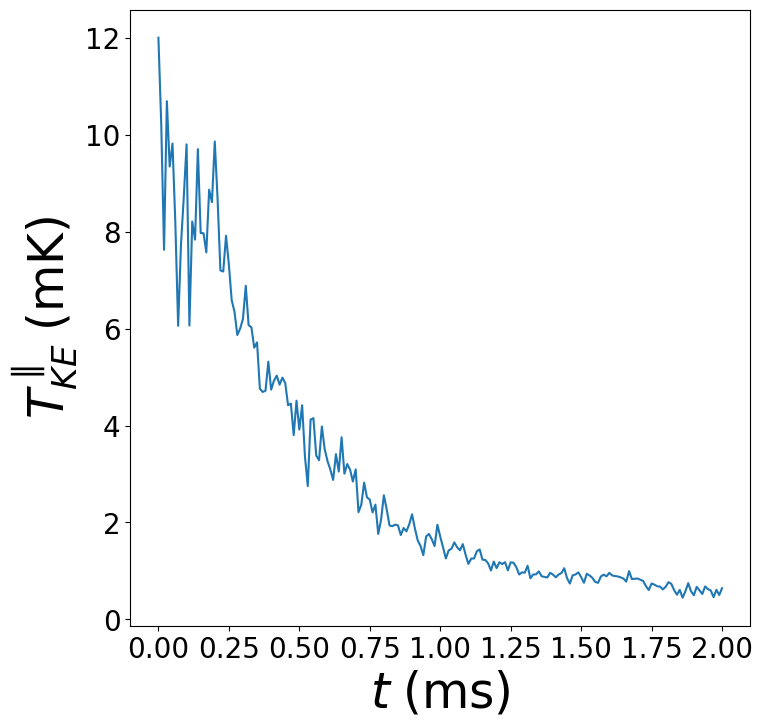

In [8]:
plt.figure(figsize=(8, 8))
for i in range(num_files):
    Temp_arr = axial_temp_arr(vel_rot3D[i], num_particles, times_rec,write_per)
    plt.plot(1.0e3 * Temp_arr[:,0], Temp_arr[:,1]*10**3)
    plt.xlabel(r'$t\;(\rm{ms})$',fontsize = 35)
    plt.ylabel(r'$T_{KE}^{\parallel}\;(\rm{mK})$',fontsize = 35)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    print(Temp_arr[0,1]*10**3) 
    
ax = plt.gca()
ax.yaxis.get_offset_text().set_fontsize(40)

Plotting the planar kinetic energy:

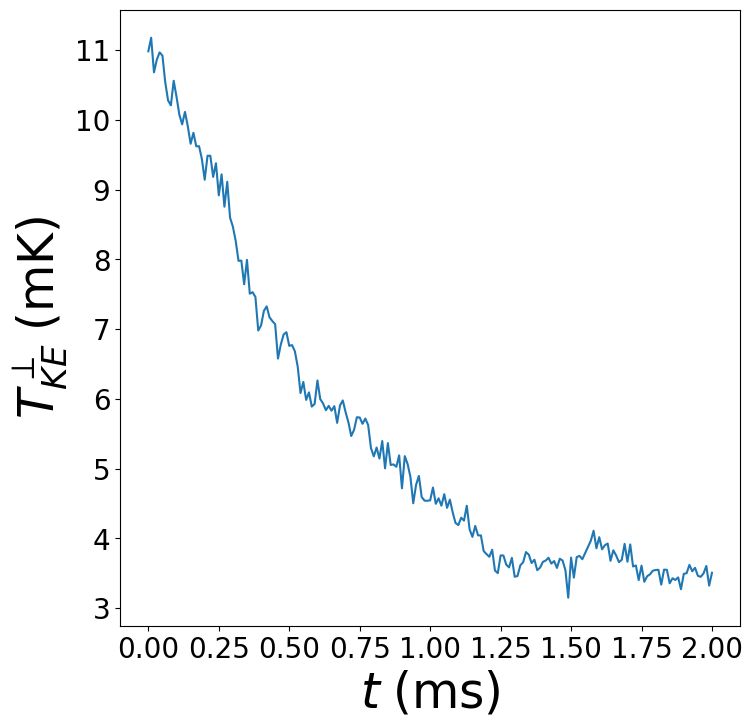

In [9]:
plt.figure(figsize=(8, 8))
for i in range(num_files):
    Temp_arr = planar_temp_arr(vel_rot3D[i], num_particles, times_rec,write_per)
    plt.plot(1.0e3 * Temp_arr[:,0], Temp_arr[:,1]*10**3)
    plt.xlabel(r'$t\;(\rm{ms})$',fontsize = 35)
    plt.ylabel(r'$T_{KE}^{\perp}\;(\rm{mK})$',fontsize = 35)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

Plotting the potential energy

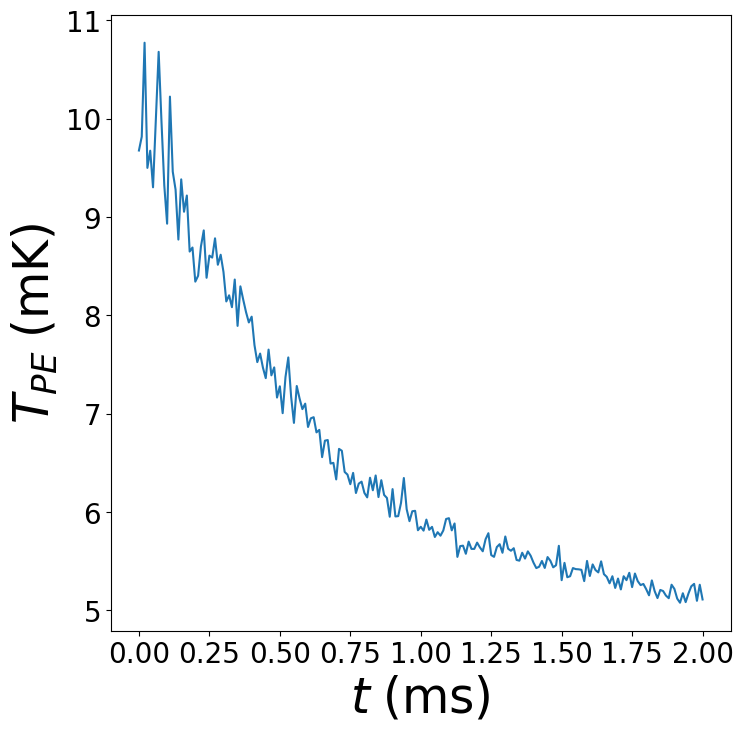

In [10]:
#load in energies from Metropolis-Hastings initialization of potential energy
pe_MH = np.loadtxt("energies_091026.csv")
#the first entry is the energy of the equilibrium configuration
pe_eq = pe_MH[0]/num_particles

plt.figure(figsize=(8, 8))
for i in range(num_files):
    PE_arr =PE_no_vel_fmm(pos_rot3D[i,:,:,:], vel_rot3D[i,:,:,:], num_particles, pos_rot3D[i,:,:,:].shape[0],write_per)
    plt.plot(1.0e3 * PE_arr[:,0]/2,  (PE_arr[:,1]-pe_eq)*(2/3)/kb*10**3) 
    plt.xlabel(r'$t\;(\rm{ms})$',fontsize = 35)
    plt.ylabel(r'$T_{PE}\;(\rm{mK})$',fontsize = 35)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
ax = plt.gca()
ax.yaxis.get_offset_text().set_fontsize(40)